This notebook is for extracting features from each layer in the DINO V3 ViT model, with the same images shown to the mouse. save the features for comparing with the mouse brain representation.

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, DINOv3ViTModel

device = "cuda" if torch.cuda.is_available() else "cpu"
repo_id = "facebook/dinov3-vitb16-pretrain-lvd1689m"
token = ''

processor = AutoImageProcessor.from_pretrained(repo_id, token=token)
model = DINOv3ViTModel.from_pretrained(repo_id, token=token).to(device)
model.eval()

print("device:", device)
print("hidden_size:", model.config.hidden_size)
print("num_hidden_layers:", model.config.num_hidden_layers)
print("image_size(config):", getattr(model.config, "image_size", None))
print("patch_size:", model.config.patch_size)
print("num_register_tokens:", getattr(model.config, "num_register_tokens", None))

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

device: cuda
hidden_size: 768
num_hidden_layers: 12
image_size(config): 224
patch_size: 16
num_register_tokens: 4


In [2]:
# load images
import os
datapath = '../data'
filename = 'miguel_passive8x4.mat'
filepath = os.path.join(datapath, filename)
# load matlab mat file
from scipy.io import loadmat
img_mat = loadmat(filepath)
img = img_mat['img'].astype(np.float32)
images_gray = np.transpose(img, (2, 0, 1))
print('img:', images_gray.shape, images_gray.min(), images_gray.max())
print("num images:", len(images_gray))
# each 4 images belong to the same category
img_class = np.repeat(np.arange(len(images_gray) // 4), 4)
print("img_class:", img_class)

img: (32, 150, 600) 0.0 255.0
num images: 32
img_class: [0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5 6 6 6 6 7 7 7 7]


In [3]:
images_rgb = []
for i in range(len(images_gray)):
    im = images_gray[i]

    im = Image.fromarray(im.astype(np.uint8))

    # ensure size 64x256 (H,W) -> PIL size is (W,H) = (256,64)
    if im.size != (256, 64):
        im = im.resize((256, 64), resample=Image.BICUBIC)

    # grayscale -> RGB (repeat channels)
    im = im.convert("RGB")

    images_rgb.append(im)

print("prepared images_rgb:", len(images_rgb))
print("example size/mode:", images_rgb[0].size, images_rgb[0].mode)

prepared images_rgb: 32
example size/mode: (256, 64) RGB


In [4]:
with torch.no_grad():
    inputs = processor(
        images=images_rgb,
        return_tensors="pt",
        do_resize=False,
        do_center_crop=False
    )
    # inputs typically has pixel_values: (B,3,H,W)
    for k, v in inputs.items():
        print(k, v.shape, v.dtype)

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs, output_hidden_states=True, interpolate_pos_encoding=True)
    hidden_states = outputs.hidden_states

print("len(hidden_states) =", len(hidden_states), "(= embedding + num_layers)")
print("layer0 shape:", hidden_states[0].shape)
print("last layer shape:", hidden_states[-1].shape)

pixel_values torch.Size([32, 3, 64, 256]) torch.float32
len(hidden_states) = 13 (= embedding + num_layers)
layer0 shape: torch.Size([32, 69, 768])
last layer shape: torch.Size([32, 69, 768])


In [5]:
# check the range of hidden states for each layer
for li in range(len(hidden_states)):
    hs = hidden_states[li]  # (B, seq_len, dim)
    print(f"Layer {li}: shape={hs.shape}, min={hs.min().item():.4f}, max={hs.max().item():.4f}")

Layer 0: shape=torch.Size([32, 69, 768]), min=-6.4147, max=7.5201
Layer 1: shape=torch.Size([32, 69, 768]), min=-34.9661, max=12.1115
Layer 2: shape=torch.Size([32, 69, 768]), min=-47.5718, max=21.3485
Layer 3: shape=torch.Size([32, 69, 768]), min=-5212.0581, max=10474.3926
Layer 4: shape=torch.Size([32, 69, 768]), min=-5218.7974, max=10457.2568
Layer 5: shape=torch.Size([32, 69, 768]), min=-5269.7222, max=10455.1055
Layer 6: shape=torch.Size([32, 69, 768]), min=-5311.8345, max=10454.3682
Layer 7: shape=torch.Size([32, 69, 768]), min=-5370.8955, max=10454.3125
Layer 8: shape=torch.Size([32, 69, 768]), min=-5666.2856, max=10455.1260
Layer 9: shape=torch.Size([32, 69, 768]), min=-5747.6445, max=10456.2324
Layer 10: shape=torch.Size([32, 69, 768]), min=-5901.8164, max=10459.2070
Layer 11: shape=torch.Size([32, 69, 768]), min=-15183.6152, max=10567.3467
Layer 12: shape=torch.Size([32, 69, 768]), min=-14875.5166, max=10613.1299


In [6]:
# save the hidden states as array with shape (num_layers, B, seq_len, dim)
hidden_states_array = torch.stack(hidden_states, dim=0).cpu().numpy()
print("hidden_states_array shape:", hidden_states_array.shape)
np.save("dino_vit_hidden_states.npy", hidden_states_array)

# zscore the patch tokens across sequence dimension
mean_all = hidden_states_array.mean(axis=-1, keepdims=True)
std_all = hidden_states_array.std(axis=-1, keepdims=True)
hidden_states_array_zscore = (hidden_states_array - mean_all) / (std_all + 1e-6)
# check the range of zscored hidden states for each layer
mean_zscore = hidden_states_array_zscore.mean(axis=-1)
std_zscore = hidden_states_array_zscore.std(axis=-1)
print("mean_zscore shape:", mean_zscore.shape, mean_zscore.min(), mean_zscore.max())
print("std_zscore shape:", std_zscore.shape, std_zscore.min(), std_zscore.max())

hidden_states_array shape: (13, 32, 69, 768)
mean_zscore shape: (13, 32, 69) -2.4835268e-08 2.4835268e-08
std_zscore shape: (13, 32, 69) 0.9999809 1.0000001


In [7]:
# pool the patch tokens by mean across sequence dimension (excluding cls token)
patch_start = 1 + model.config.num_register_tokens
patch_tokens = hidden_states_array_zscore[:, :, patch_start:, :]  # (num_layers, B, num_patches, dim)
pooled_patch_tokens = patch_tokens.mean(axis=2)
print("pooled_patch_tokens shape:", pooled_patch_tokens.shape)

# cls token is the first token in the sequence
cls_tokens = hidden_states_array_zscore[:, :, 0, :]  # (num_layers, B, dim)
print("cls_tokens shape:", cls_tokens.shape)

pooled_patch_tokens shape: (13, 32, 768)
cls_tokens shape: (13, 32, 768)


In [8]:
# save the pooled patch tokens and cls tokens
np.save("outputs/dino_vit_pooled_patch_tokens.npy", pooled_patch_tokens)
np.save("outputs/dino_vit_cls_tokens.npy", cls_tokens)

In [9]:
mean_patch_last = pooled_patch_tokens[-1]  # (B, dim)
cls_last = cls_tokens[-1]  # (B, dim)
print("cls_last:", cls_last.shape, cls_last.min(), cls_last.max())
print("mean_patch_last:", mean_patch_last.shape, mean_patch_last.min(), mean_patch_last.max())

cls_last: (32, 768) -9.231164 6.487107
mean_patch_last: (32, 768) -20.735407 4.4798307


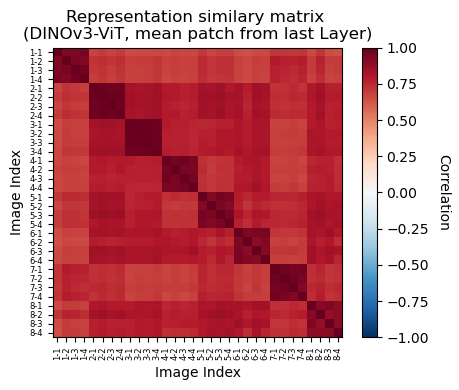

In [10]:
# use the mean patch last as the image representation to do a correlation matrix visualization
# use matplotlib only no seaborn
import matplotlib.pyplot as plt
import numpy as np
corr = np.corrcoef(mean_patch_last)
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similary matrix \n(DINOv3-ViT, mean patch from last Layer)")
# show image as 1-1, 1-2 etc, as class 1, instance 1 and 2
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.xticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

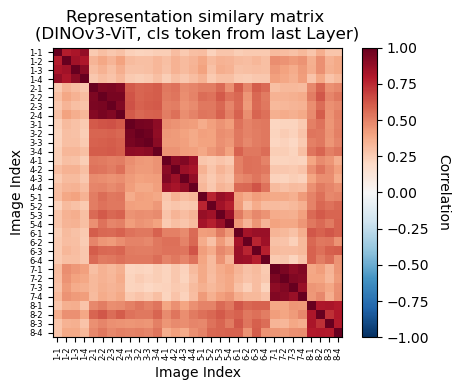

In [11]:
# check the representation of cls token
correlation_cls = np.corrcoef(cls_last)
plt.figure(figsize=(5,4))
plt.imshow(correlation_cls, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similary matrix \n(DINOv3-ViT, cls token from last Layer)")
# show image as 1-1, 1-2 etc, as class 1, instance 1 and 2
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.xticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [12]:
print("pooled_patch_tokens shape:", pooled_patch_tokens.shape)
print("cls_tokens shape:", cls_tokens.shape)

nlayers, nimg, dim = pooled_patch_tokens.shape
print(f"Number of layers: {nlayers}, Number of images: {nimg}, Dimension: {dim}")

# for each layer, compute the correlation matrix of the pooled patch tokens across images
patch_rsm = np.zeros((nlayers, nimg, nimg))
cls_rsm = np.zeros((nlayers, nimg, nimg))
for li in range(nlayers):
    patch_rsm[li] = np.corrcoef(pooled_patch_tokens[li])
    cls_rsm[li] = np.corrcoef(cls_tokens[li])

pooled_patch_tokens shape: (13, 32, 768)
cls_tokens shape: (13, 32, 768)
Number of layers: 13, Number of images: 32, Dimension: 768


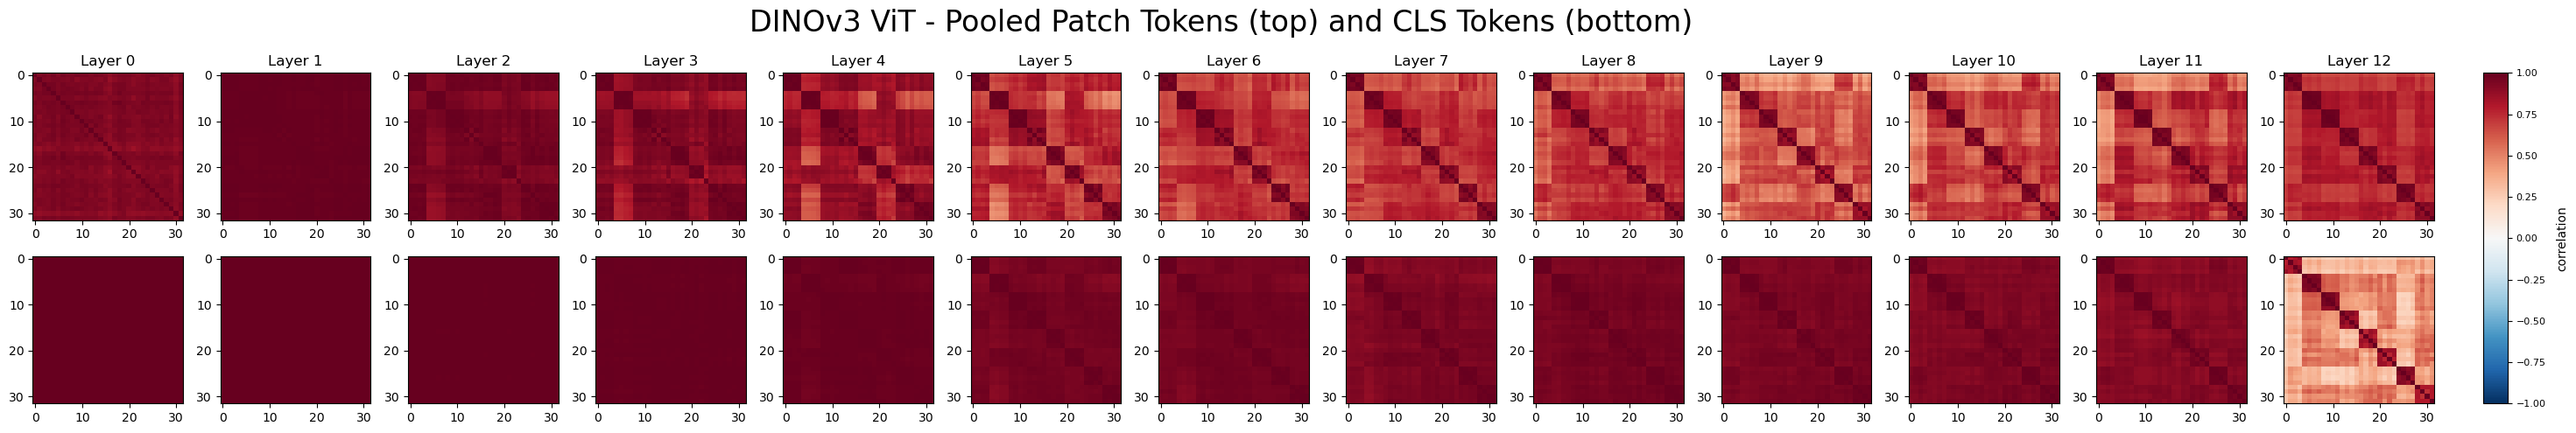

In [16]:
# visualize the rsm for each layer
nlayers = 13
fig, axes = plt.subplots(2, nlayers, figsize=(2*nlayers+2, 5))

for li in range(nlayers):
    img = axes[0, li].imshow(patch_rsm[li],
                             cmap='RdBu_r',
                             vmin=-1, vmax=1,
                             aspect='auto')
    axes[0, li].set_title(f"Layer {li}")
    
    axes[1, li].imshow(cls_rsm[li],
                       cmap='RdBu_r',
                       vmin=-1, vmax=1,
                       aspect='auto')

plt.suptitle(
    "DINOv3 ViT - Pooled Patch Tokens (top) and CLS Tokens (bottom)",
    fontsize=24
)

plt.tight_layout()

# ---- Add shared colorbar outside ----
pos = axes[0, -1].get_position()

cax = fig.add_axes([
    pos.x1 + 0.02,     # slight right shift
    axes[1, 0].get_position().y0,  # bottom of bottom row
    0.01,             # width
    axes[0, 0].get_position().y1 - axes[1, 0].get_position().y0  # full height
])

cbar = fig.colorbar(img, cax=cax)
cbar.set_label('correlation', labelpad=8)
cbar.ax.tick_params(labelsize=8)

# save
plt.savefig("../figures/dinoV3_corr_matrix.png",
            dpi=300,
            bbox_inches='tight')

plt.show()